# 向量範數：概念、幾何與 NumPy 範例

本 Notebook 整合向量範數的基本定義、常見類型、幾何化理解，以及實務用途。範數的核心功能，是把多維向量轉換成一個非負的純量，用來表示「大小」、「距離」、「誤差」或「模型複雜度」。

## 1. 什麼是向量範數？

對一個向量 $\mathbf{x} \in \mathbb{R}^n$，範數通常記為 $\|\mathbf{x}\|$，用來衡量向量的大小。

一個合法的範數通常需要滿足三個性質：

1. **非負性**：$\|\mathbf{x}\| \ge 0$，且只有 $\mathbf{x}=\mathbf{0}$ 時等於 0。
2. **齊次性**：$\|\alpha \mathbf{x}\| = |\alpha|\|\mathbf{x}\|$。
3. **三角不等式**：$\|\mathbf{x}+\mathbf{y}\| \le \|\mathbf{x}\| + \|\mathbf{y}\|$。

有了範數，就可以進一步定義距離：

$$
d(\mathbf{x}, \mathbf{y}) = \|\mathbf{x} - \mathbf{y}\|
$$

In [1]:
import numpy as np

x = np.array([3, 4])
y = np.array([1, 1])

print("x =", x)
print("y =", y)
print("L2 norm of x:", np.linalg.norm(x, ord=2))
print("Distance between x and y:", np.linalg.norm(x - y, ord=2))

x = [3 4]
y = [1 1]
L2 norm of x: 5.0
Distance between x and y: 3.605551275463989


## 2. 常見向量範數

### $L^1$ 範數：曼哈頓範數

$$
\|\mathbf{x}\|_1 = \sum_{i=1}^n |x_i|
$$

它把每個分量的絕對值相加，常用於鼓勵稀疏解。

### $L^2$ 範數：歐幾里得範數

$$
\|\mathbf{x}\|_2 = \sqrt{x_1^2 + x_2^2 + \cdots + x_n^2}
$$

這是最常見的幾何長度，來自畢氏定理。

### $L^\infty$ 範數：最大範數

$$
\|\mathbf{x}\|_\infty = \max_i |x_i|
$$

它只看絕對值最大的分量。

In [2]:
x = np.array([3, -4, 12])

l1 = np.linalg.norm(x, ord=1)
l2 = np.linalg.norm(x, ord=2)
linf = np.linalg.norm(x, ord=np.inf)

print("x =", x)
print("L1 norm:", l1)
print("L2 norm:", l2)
print("L-infinity norm:", linf)

x = [ 3 -4 12]
L1 norm: 19.0
L2 norm: 13.0
L-infinity norm: 12.0


## 3. 幾何觀點的範數

幾何化時，通常觀察的是所有「範數等於 1」的點，也就是二維平面中的單位球邊界。

$$
\|\mathbf{x}\| = 1
$$

不同範數對「距離 1」的定義不同，因此邊界形狀不同：

- $L^1$：$|x_1| + |x_2| = 1$，形成菱形。
- $L^2$：$x_1^2 + x_2^2 = 1$，形成圓形。
- $L^\infty$：$\max(|x_1|, |x_2|)=1$，形成正方形。

這說明範數不只是計算公式，它實際上定義了空間中的幾何。

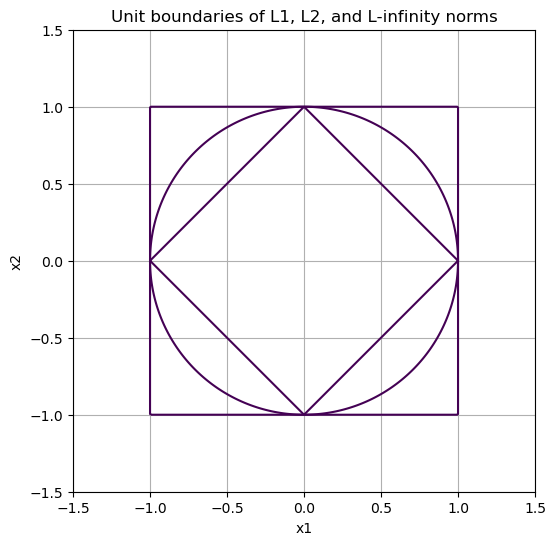

In [ ]:
import matplotlib.pyplot as plt

# 建立平面網格
grid = np.linspace(-1.5, 1.5, 500)
X, Y = np.meshgrid(grid, grid)

L1 = np.abs(X) + np.abs(Y)
L2 = np.sqrt(X**2 + Y**2)
Linf = np.maximum(np.abs(X), np.abs(Y))

plt.figure(figsize=(6, 6))
plt.contour(X, Y, L1, levels=[1])
plt.contour(X, Y, L2, levels=[1])
plt.contour(X, Y, Linf, levels=[1])
plt.gca().set_aspect("equal", adjustable="box")
plt.title("Unit boundaries of L1, L2, and L-infinity norms")
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid(True)
plt.show()

## 4. 一般化的 $L^p$ 範數

對 $p \ge 1$，$L^p$ 範數定義為：

$$
\|\mathbf{x}\|_p = \left(\sum_{i=1}^n |x_i|^p\right)^{1/p}
$$

當 $p=1$ 時是 $L^1$，當 $p=2$ 時是 $L^2$，當 $p \to \infty$ 時趨近 $L^\infty$。

幾何上，$p$ 越大，單位球越接近正方形；$p$ 越接近 1，形狀越尖。若 $0 < p < 1$，通常不稱為範數，因為會違反三角不等式。

In [4]:
x = np.array([2, -3, 6])

for p in [1, 2, 3, 4, np.inf]:
    print(f"p = {p}, norm = {np.linalg.norm(x, ord=p):.4f}")

p = 1, norm = 11.0000
p = 2, norm = 7.0000
p = 3, norm = 6.3080
p = 4, norm = 6.1092
p = inf, norm = 6.0000


### $L^p$ 單位球的形狀變化

下面視覺化不同 $p$ 值下的單位邊界。

/var/folders/p1/2yp706d10gq90hjfpmfzcq9h0000gn/T/ipykernel_6700/1218902258.py:5: RuntimeWarning: overflow encountered in power
  Lp = (np.abs(X) ** p + np.abs(Y) ** p) ** (1 / p)


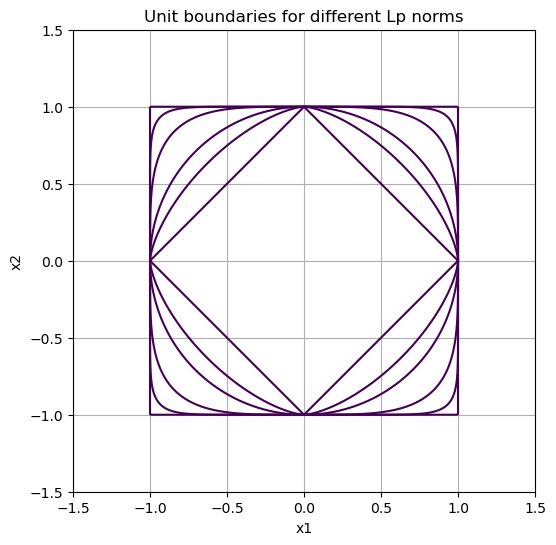

In [12]:
ps = [1, 1.5, 2, 4, 10, 9999]

plt.figure(figsize=(6, 6))
for p in ps:
    Lp = (np.abs(X) ** p + np.abs(Y) ** p) ** (1 / p)
    plt.contour(X, Y, Lp, levels=[1])

plt.gca().set_aspect("equal", adjustable="box")
plt.title("Unit boundaries for different Lp norms")
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid(True)
plt.show()

## 5. 加權範數與 Mahalanobis 型範數

有些情況下，不同方向的重要性不同。這時可以使用加權範數，例如：

$$
\|\mathbf{x}\| = \sqrt{\mathbf{x}^T A \mathbf{x}}
$$

其中 $A$ 是正定矩陣。若 $A$ 不是單位矩陣，單位球通常會從圓變成橢圓。這類形式常出現在統計、機器學習與資料標準化中。

In [ ]:
A = np.array([[3, 1], [1, 2]])

v = np.array([1, 2])

weighted_norm = np.sqrt(v.T @ A @ v)
print("v =", v)
print("A =\n", A)
print("sqrt(v.T @ A @ v) =", weighted_norm)

v = [1 2]
A =
 [[3 1]
 [1 2]]
sqrt(v.T @ A @ v) = 3.872983346207417


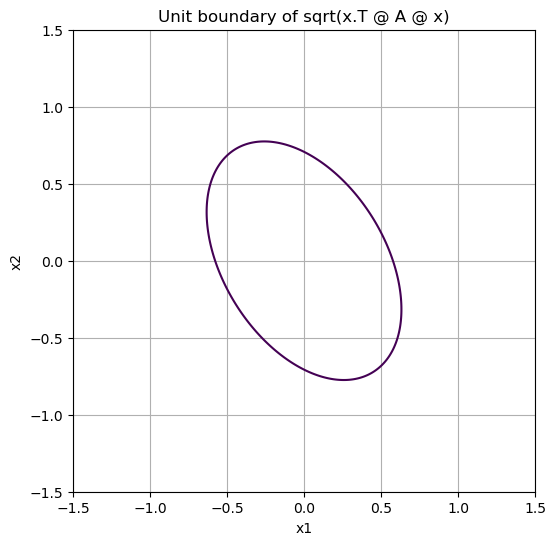

In [ ]:
Q = A[0, 0] * X**2 + 2 * A[0, 1] * X * Y + A[1, 1] * Y**2

plt.figure(figsize=(6, 6))
plt.contour(X, Y, Q, levels=[1])
plt.gca().set_aspect("equal", adjustable="box")
plt.title("Unit boundary of sqrt(x.T @ A @ x)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid(True)
plt.show()

## 6. 矩陣範數

範數也可以用在矩陣上。常見例子包括：

### Frobenius norm

$$
\|A\|_F = \sqrt{\sum_{i,j} a_{ij}^2}
$$

它可以理解成把矩陣所有元素攤平成一個向量後，再取 $L^2$ 範數。

### Operator norm

$$
\|A\| = \max_{\|x\|=1} \|Ax\|
$$

它衡量矩陣作為線性變換時，最多可以把向量放大多少。

In [ ]:
M = np.array([[1, 2, 3], [4, 5, 6]])

print("M =\n", M)
print("Frobenius norm:", np.linalg.norm(M, ord="fro"))
print("Matrix 2-norm / spectral norm:", np.linalg.norm(M, ord=2))
print("Matrix 1-norm:", np.linalg.norm(M, ord=1))
print("Matrix infinity norm:", np.linalg.norm(M, ord=np.inf))

M =
 [[1 2 3]
 [4 5 6]]
Frobenius norm: 9.539392014169456
Matrix 2-norm / spectral norm: 9.508032000695723
Matrix 1-norm: 9.0
Matrix infinity norm: 15.0


## 7. 範數的用途

範數的用途可以概括為三個功能：量化、比較、控制。

### 7.1 衡量距離

範數可用來定義兩個向量之間的距離。

### 7.2 衡量誤差

若 $\hat{x}$ 是估計值、$x$ 是真值，則誤差可以寫成：

$$
\|x - \hat{x}\|
$$

不同範數會強調不同誤差型態，例如 $L^2$ 強調整體平均，$L^\infty$ 強調最壞情況。

### 7.3 最佳化與正則化

在機器學習中，範數常被用來限制模型參數大小：

$$
\min_w \; \text{loss}(w) + \lambda \|w\|
$$

- $L^2$ regularization：讓權重整體變小。
- $L^1$ regularization：容易產生稀疏解，也就是許多權重變成 0。

In [9]:
# 誤差範例
true = np.array([10.0, 20.0, 30.0])
pred = np.array([12.0, 19.0, 27.0])
error = true - pred

print("error vector:", error)
print("L1 error:", np.linalg.norm(error, ord=1))
print("L2 error:", np.linalg.norm(error, ord=2))
print("L-infinity error:", np.linalg.norm(error, ord=np.inf))

error vector: [-2.  1.  3.]
L1 error: 6.0
L2 error: 3.7416573867739413
L-infinity error: 3.0


In [ ]:
# 正則化概念範例
w = np.array([0.8, -0.2, 0.0, 1.5, -3.0])
lambda_ = 0.1

l1_penalty = lambda_ * np.linalg.norm(w, ord=1)
l2_penalty = lambda_ * np.linalg.norm(w, ord=2) ** 2

print("weights:", w)
print("L1 penalty:", l1_penalty)
print("L2 squared penalty:", l2_penalty)

weights: [ 0.8 -0.2  0.   1.5 -3. ]
L1 penalty: 0.55
L2 squared penalty: 1.193


## 8. 小結

範數提供一套把多維對象轉換成單一尺度的方法。它不只是公式，也會定義幾何形狀、距離概念、誤差度量與最佳化行為。

可以用以下方式記憶：

- $L^1$：絕對值相加，幾何上是菱形，常與稀疏性有關。
- $L^2$：平方和開根號，幾何上是圓，常與平滑與能量有關。
- $L^\infty$：取最大分量，幾何上是正方形，常用於最壞情況控制。
- $L^p$：統一上述形式，$p$ 改變時會改變空間的幾何。
- 加權或 Mahalanobis 型範數：引入方向與相關性，單位球通常變成橢圓。